# Decision Tree Algorithm

In [ ]:
DECISION

1)Read CSV file
2)Check Null Value
3)required to get dummies.
4)Define X & y
5)Split data Into train and test
6)Train Decision Tree Model
7)Prediction
8)Model Evaluation
9)Assigning CM Values find TP,TN,FP,FN
10) Calculate Accuracy, Error Rate, Sensitivity, Specificit

In [56]:
# 1)
import pandas as pd
df = pd.read_csv('DecisionTreeDataset.csv')
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,High,Good,High,Good,Yes
1,Medium,Good,High,Good,Yes
2,Low,Bad,Low,Good,No
3,Low,Good,Low,Bad,No
4,High,Good,High,Bad,Yes
5,High,Good,High,Good,Yes
6,Medium,Bad,Low,Bad,No
7,Medium,Bad,Low,Good,No
8,High,Bad,High,Good,Yes
9,Medium,Good,High,Good,Yes


In [57]:
# 2)
print(df.isnull().sum())

CGPA                 0
Communication        0
Apptitude            0
Programming Skill    0
Job Offered          0
dtype: int64


In [58]:
# 3)
df = pd.get_dummies(data=df, columns=['CGPA', 'Communication', 'Apptitude', 'Programming Skill'], drop_first=True)
df

,Job Offered,CGPA_Low,CGPA_Medium,Communication_Good,Apptitude_Low,Programming Skill_Good
0,Yes,False,False,True,False,True
1,Yes,False,True,True,False,True
2,No,True,False,False,True,True
3,No,True,False,True,True,False
4,Yes,False,False,True,False,False
5,Yes,False,False,True,False,True
6,No,False,True,False,True,False
7,No,False,True,False,True,True
8,Yes,False,False,False,False,True
9,Yes,False,True,True,False,True


In [59]:
# 4)
X = df.drop('Job Offered', axis=1)
y = df['Job Offered']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (18, 5)
y shape: (18,)


In [60]:
# 5)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (14, 5)
Testing data size: (4, 5)
Training data size: (14,)
Testing data size: (4,)


In [61]:
# 6) 
from sklearn.tree import DecisionTreeClassifier,plot_tree
model = DecisionTreeClassifier(criterion='entropy',max_depth=10,random_state=42)
model.fit(X_train, y_train)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
# 7)
y_pred = model.predict(X_test)
y_pred

array(['Yes', 'Yes', 'No', 'Yes'], dtype=object)

In [63]:
# 8)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[0, 0],
       [1, 3]])

In [64]:
# 9) 
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)


TN: 0
FP: 0
FN: 1
TP: 3


In [65]:
# 10) 
# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)
# Error Rate
error_rate = (FP + FN) / (TP + TN + FP + FN)
# error_rate = 1 - accuracy
# Sensitivity/ recall score
sensitivity = TP / (TP + FN)
# Specificity
specificity = TN / (TN + FP)
# Precision
precision=TP/(TP+FP)
print("Accuracy=", accuracy)
print("Error Rate=", error_rate)
print("Sensitivity=", sensitivity)
print("Specificity=", specificity)
print("precision=", precision)

Accuracy= 0.75
Error Rate= 0.25
Sensitivity= 0.75
Specificity= nan
precision= 1.0


C:\Users\LJENG\AppData\Local\Temp\ipykernel_4712\1846199045.py:10: RuntimeWarning: invalid value encountered in scalar divide
  specificity = TN / (TN + FP)


## Second TRICK by using function

In [66]:
from sklearn.metrics import accuracy_score, recall_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
# Error Rate
error_rate = 1 - accuracy
# Sensitivity/ recall score
recall = recall_score(y_test, y_pred)

print("Accuracy=", accuracy)
print("Error Rate=", error_rate)
print("Sensitivity=", recall)

ValueError: pos_label=1 is not a valid label. It should be one of ['No', 'Yes']

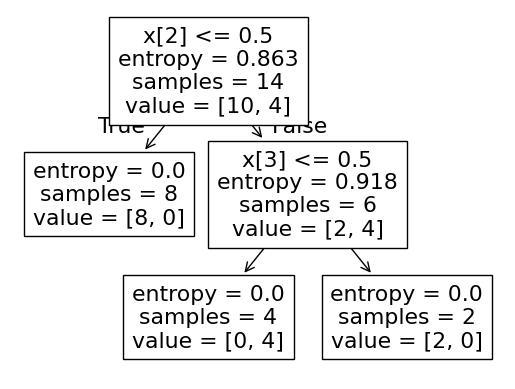

In [34]:
import matplotlib.pyplot as plt
plot_tree(model)
plt.show()

## CLASSIFICATION REPORT

In [35]:
from sklearn.metrics import classification_report

print("Classification Report:",classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

          No       0.00      0.00      0.00         0
         Yes       1.00      0.75      0.86         4

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### f1-score=2*(precision*recall)/(precision+recall)

### Example 

In [37]:
# 1)
import pandas as pd
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [38]:
# 2)
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [39]:
# 3) not required

In [40]:
# 4)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [41]:
# 5)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (614, 8)
Testing data size: (154, 8)
Training data size: (614,)
Testing data size: (154,)


In [42]:
# 6) 
from sklearn.tree import DecisionTreeClassifier,plot_tree
model = DecisionTreeClassifier(criterion='entropy',max_depth=25,random_state=42)
model.fit(X_train, y_train)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
# 7)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

In [44]:
# 8)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[76, 23],
       [20, 35]])

In [45]:
# 9) 
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 76
FP: 23
FN: 20
TP: 35


In [46]:
# 10) 
# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)
# Error Rate
error_rate = (FP + FN) / (TP + TN + FP + FN)
# error_rate = 1 - accuracy
# Sensitivity/ recall score
sensitivity = TP / (TP + FN)
# Specificity
specificity = TN / (TN + FP)
# Precision
precision=TP/(TP+FP)
print("Accuracy=", accuracy)
print("Error Rate=", error_rate)
print("Sensitivity=", sensitivity)
print("Specificity=", specificity)
print("precision=", precision)

Accuracy= 0.7207792207792207
Error Rate= 0.2792207792207792
Sensitivity= 0.6363636363636364
Specificity= 0.7676767676767676
precision= 0.603448275862069


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# a) Load the windpower dataset
df = pd.read_csv('windpower.csv')
df

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275
...,...,...
495,0.0,24.775
496,0.0,24.850
497,0.0,24.875
498,0.0,24.950


In [86]:
# b) Check for missing values and remove them permanently
print(df.isnull().sum())
df.dropna(inplace=True)

Power (kW)          3
Wind speed (m/s)    5
dtype: int64


In [87]:
# c) Split the dataset into training (75%) and testing (25%)
X = df[['Wind speed (m/s)']] 
y = df['Power (kW)']
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

X shape: (492, 1)
y shape: (492,)

Training data size: (369, 1)
Testing data size: (123, 1)
Training data size: (369,)
Testing data size: (123,)


In [89]:
# d, e, h) Train models, Predict, and Print Metrics/Coefficients
degrees = [3, 4, 5, 6]
MSE = []
for i in degrees:
    # d) Polynomial features create karna
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(X_train)
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    X_test_poly = poly.transform(X_test)
    # e) Prediction
    y_pred = lr.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    MSE.append(mse)
    R2_score = r2_score(y_test, y_pred)
    print("Degree=",i)
    print("MSE=",mse)
    print("R2_score=",R2_score)

Degree= 3
MSE= 270.0250095299955
R2_score= 0.8539264141973832
Degree= 4
MSE= 209.3184510784717
R2_score= 0.8867664266472862
Degree= 5
MSE= 212.4228861347375
R2_score= 0.8850870416105098
Degree= 6
MSE= 169.170104193283
R2_score= 0.9084852037478769


In [ ]:
import matplotlib.pyplot as plt
plt.plot(degrees,MSE,'')